# Chapter 21: Markets, Teams, and Institutions

A team adds a shortcut between two workflow stages. Every participant sees a privately attractive route, yet their collective routing can increase delay. The missing ingredient is congestion: each choice changes the cost other participants face.

This notebook solves a symmetric continuous-flow Braess construction. Two outer routes share a new shortcut route, with linear congestion and fixed delays. It calculates private equilibrium and total social travel time, then compares a toll intervention and an exact social optimum. The example is a declared institution model. It does not estimate a real market or suggest that every new workflow interface causes a paradox.

**Outcome:** Compare Braess equilibrium, social optimum, tolls, and overhead.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let total demand be D. Symmetry assigns x to each outer route and z to the shortcut, so 2x+z=D. Each congestible edge carries x+z and takes time v=(x+z)/capacity. Outer path time is v+c; shortcut time is 2v+overhead. The shortcut also pays a private toll.

At an interior equilibrium, used routes have equal private cost. Solving v+c=2v+overhead+toll gives z=2 capacity(c-overhead-toll)-D, clipped to [0,D]. Boundary clipping handles unused outer or shortcut routes. Without the shortcut, outer flow is D/2 and total travel time is D[D/(2 capacity)+c].

Social travel time excludes toll transfers and equals 2x(v+c)+z(2v+overhead). After substitution it is (D+z)^2/(2 capacity)+c(D-z)+overhead*z. This convex quadratic is minimized at z=capacity(c-overhead)-D, clipped to [0,D]. The price of anarchy compares equilibrium social time with that minimum, not with toll-inclusive private expense.

## A calculation you can run

Declare demand, congestion capacity, outer constant delay, shortcut overhead, and toll. Validation requires positive demand and capacity and nonnegative other quantities. The function computes symmetric equilibrium flow, path costs, total delay, optimal shortcut flow, and toll revenue.

The figure varies shortcut flow from zero to total demand and plots exact social travel time. Its minimum should match the reported optimum. In the changed case add toll 0.5 without changing physical travel times. Predict how it shifts equilibrium, then compare social cost. The transfer case reduces demand, checking that a shortcut need not worsen performance under every loading condition.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 21
inputs = {'demand': 1,
 'capacity': 1,
 'constant_time': 1,
 'shortcut_overhead': 0,
 'shortcut_toll': 0}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 21: congestion-incentives
Can a faster-looking route make the whole workflow slower?
Evidence: constructed teaching example

Calculated quantities:
{
  "without_shortcut_total_time": 1.5,
  "equilibrium_shortcut_flow": 1.0,
  "equilibrium_outer_flow_each": 0.0,
  "equilibrium_social_time": 2.0,
  "equilibrium_private_outer_time": 2.0,
  "equilibrium_private_shortcut_time": 2.0,
  "optimal_shortcut_flow": 0,
  "optimal_social_time": 1.5,
  "price_of_anarchy": 1.333333333,
  "braess_worsens": true,
  "toll_revenue": 0.0
}

Interpretation:
A new route can change private incentives and increase total delay. Tolls enter private cost; toll payments are excluded from travel-time social cost.

Assumptions:
- Symmetric continuous flow, linear congestible edges, constant outer edges.
- All travelers choose minimum private path cost at nonatomic equilibrium.

Limitations:
- This construction does not estimate a real workflow equilibrium.
- Discrete teams and heterogeneous incentives need 

Without the shortcut, default total time is 1(0.5+1)=1.5. With a zero-cost shortcut, equilibrium sends all demand through it, giving path time 2 and total time 2. The social optimum uses no shortcut and remains at 1.5. Price of anarchy is 2/1.5=4/3.

A toll 0.5 changes the equilibrium shortcut flow to zero. Outer private time is 1.5, while an unused shortcut would also cost 1.5 including toll. Total travel time returns to 1.5. The toll affects incentives; it is not counted as destroyed travel time or an extra physical delay.

The toll 0.5 sits exactly at the break-even value, so this teaching case is knife-edge. At toll 0.49 the lab returns shortcut flow 0.02 and equilibrium social time 1.5002, and at 0.51 it returns flow 0 and time 1.5. Try nearby tolls to see the threshold rather than reading 0.5 as a robust remedy.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


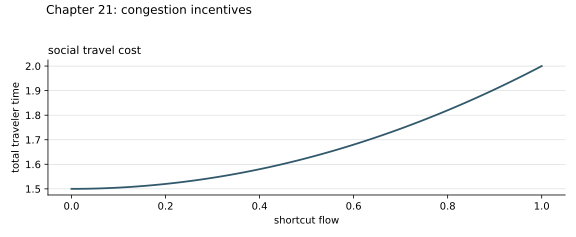

In [3]:
display(SVG(figure_svg(report)))

**Figure 21.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

The paradox relies on a particular network and demand regime. At low demand, the shortcut can be socially useful and privately efficient. Presenting the default construction as a law against connectivity would erase those conditions.

Institutional metrics can also confuse transfers with resource costs. A toll payment changes who bears money but is excluded from this travel-time objective. A real institution may care about distributional effects or administrative overhead, which should be modeled separately. Shortcut overhead here is a real delay and therefore enters social cost.

Continuous equilibrium assumes many small participants choosing minimum private cost. A small team with indivisible jobs, strategic coordination, or centralized routing may behave differently. The calculation is an exact finite model result under those assumptions, not a fitted causal claim about organizational performance.

Chapter 21: congestion-incentives
Can a faster-looking route make the whole workflow slower?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "without_shortcut_total_time": 1.5,
  "equilibrium_shortcut_flow": 0,
  "equilibrium_outer_flow_each": 0.5,
  "equilibrium_social_time": 1.5,
  "equilibrium_private_outer_time": 1.5,
  "equilibrium_private_shortcut_time": 1.5,
  "optimal_shortcut_flow": 0,
  "optimal_social_time": 1.5,
  "price_of_anarchy": 1.0,
  "braess_worsens": false,
  "toll_revenue": 0.0
}

Interpretation:
A new route can change private incentives and increase total delay. Tolls enter private cost; toll payments are excluded from travel-time social cost.

Assumptions:
- Symmetric continuous flow, linear congestible edges, constant outer edges.
- All travelers choose minimum private path cost at nonatomic equilibrium.

Limitations:
- This construction does not estimate a real workflow equilibrium.
- Discrete teams and heterogeneous incentives need

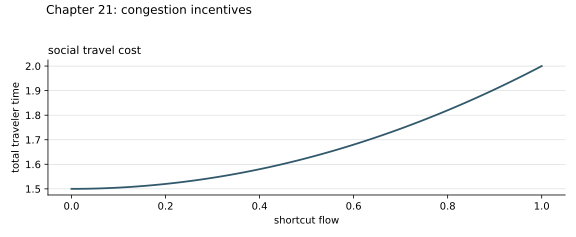

In [4]:
changed_inputs = {'demand': 1,
 'capacity': 1,
 'constant_time': 1,
 'shortcut_overhead': 0,
 'shortcut_toll': 0.5}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 21.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

At demand 0.5, capacity 1, and constant delay 1, equilibrium sends all flow through the shortcut. Its total time is 0.5, below the no-shortcut total 0.625. The social optimum also uses shortcut flow 0.5, so price of anarchy is 1.

For local workflow analysis, identify who selects routes and which costs they internalize. Separate routing overhead from incentive charges and preserve demand units. Compare local choice with a collective objective before adding a new interface. If route delays are estimated, collect measurements under several loads rather than assuming a linear congestion law.

In [5]:
transfer_inputs = {'demand': 0.5,
 'capacity': 1,
 'constant_time': 1,
 'shortcut_overhead': 0,
 'shortcut_toll': 0}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 21: congestion-incentives
Can a faster-looking route make the whole workflow slower?
Evidence: constructed transfer example

Calculated quantities:
{
  "without_shortcut_total_time": 0.625,
  "equilibrium_shortcut_flow": 0.5,
  "equilibrium_outer_flow_each": 0.0,
  "equilibrium_social_time": 0.5,
  "equilibrium_private_outer_time": 1.5,
  "equilibrium_private_shortcut_time": 1.0,
  "optimal_shortcut_flow": 0.5,
  "optimal_social_time": 0.5,
  "price_of_anarchy": 1.0,
  "braess_worsens": false,
  "toll_revenue": 0.0
}

Interpretation:
A new route can change private incentives and increase total delay. Tolls enter private cost; toll payments are excluded from travel-time social cost.

Assumptions:
- Symmetric continuous flow, linear congestible edges, constant outer edges.
- All travelers choose minimum private path cost at nonatomic equilibrium.

Limitations:
- This construction does not estimate a real workflow equilibrium.
- Discrete teams and heterogeneous incentives need add

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **demand:** Positive continuous traveler or job flow in normalized units.
- **capacity:** Positive flow scale of each linear congestible edge.
- **constant_time:** Nonnegative fixed delay of each outer constant edge.
- **shortcut_overhead:** Nonnegative real delay on the shortcut.
- **shortcut_toll:** Nonnegative private incentive charge, excluded from travel-time social cost.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch21.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 21: congestion-incentives
Can a faster-looking route make the whole workflow slower?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "without_shortcut_total_time": 0.625,
  "equilibrium_shortcut_flow": 0.5,
  "equilibrium_outer_flow_each": 0.0,
  "equilibrium_social_time": 0.5,
  "equilibrium_private_outer_time": 1.5,
  "equilibrium_private_shortcut_time": 1.0,
  "optimal_shortcut_flow": 0.5,
  "optimal_social_time": 0.5,
  "price_of_anarchy": 1.0,
  "braess_worsens": false,
  "toll_revenue": 0.0
}

Interpretation:
A new route can change private incentives and increase total delay. Tolls enter private cost; toll payments are excluded from travel-time social cost.

Assumptions:
- Symmetric continuous flow, linear congestible edges, constant outer edges.
- All travelers choose minimum private path cost at nonatomic equilibrium.

Limitations:
- This construction does not estimate a real workflow equilibrium.
- Discrete teams and h

## Questions

1. Compute default price of anarchy.

2. Why exclude toll revenue from social travel time?

3. Compute transfer social optimum.

Answers: [separate solutions](../solutions/ch21.md). Try the calculation before opening them.

## Summary

Local incentives and collective outcomes can diverge. The Braess construction makes that divergence exact: a shortcut worsens default equilibrium, a toll restores efficient routing, and low-demand transfer removes the paradox. The notebook distinguishes physical overhead from private incentive charges and compares equilibrium with a convex social optimum. Its conclusions depend on the supplied network form, continuous flow, and cost law. It does not infer how a real team will respond.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-21-congestion-incentives`](../skills/maa-21-congestion-incentives/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 21.1

![Equation 21.1](../assets/math/789a238d6278b03f32dc.svg)

Equation (21.1) adds each edge's delay across all flow using that edge, producing the system's total time.

Multiply traffic on every edge by its experienced latency, then add the products over the whole network.

LaTeX source, preserved for inspection:

```latex
\operatorname{TL}(q) \;=\; \sum_{e\in\mathcal E} q_e\,\ell_e(q_e).
\tag{21.1}
```

### Equation 21.2

![Equation 21.2](../assets/math/c707158415fb2c2d45b6.svg)

Equation (21.2) bounds self-directed routing's total delay against best feasible routing when every edge delay is linear.

Divide equilibrium delay by optimal delay; under nonnegative straight-line latency rules, ratio never exceeds four thirds.

LaTeX source, preserved for inspection:

```latex
\frac{\operatorname{TL}(q^{\mathrm{NE}})}{\operatorname{TL}(q^{\star})} \;\leq\; \frac{4}{3}
\qquad\text{when every }\ell_e(q_e)=a_e q_e+b_e\text{ with }a_e,b_e\geq0.
\tag{21.2}
```

### Equation 21.3

![Equation 21.3](../assets/math/0d9a15c23069ca305b11.svg)

Equation (21.3) converts an edge's experienced delay into a local price that includes congestion imposed on existing users.

Add the direct delay to flow times its slope; for straight-line delay, double only the congestion term.

LaTeX source, preserved for inspection:

```latex
\ell^{\mathrm{mc}}_e(q_e) \;=\; \ell_e(q_e)+q_e\ell'_e(q_e),
\qquad
\ell_e(q_e)=a_e q_e+b_e\;\Longrightarrow\;\ell^{\mathrm{mc}}_e(q_e)=2a_e q_e+b_e.
\tag{21.3}
```